# Module 1 — Market Exploration
## Ohio Dental Clinic — Site Selection Analysis

**Purpose:** Market exploration and data integration. Merges all cleaned datasets into a single master dataset. Maps 10,962 Ohio dental providers against 6 candidate locations using Haversine distance. Computes competitor counts, demographic aggregations, and residents-per-dentist ratios for 15-minute and 30-minute catchment radii.

| | |
|---|---|
| **Input** | All 7 cleaned CSV files from `prep/` |
| **Output** | `master_dataset.csv`, `competitors_summary.csv`, 8 chart PNGs |
| **Key finding** | Competition spans a 12× range — from 109 providers (Ontario) to 1,316 (Indianola Ave) |

In [1]:
# LIBRARIES
import pandas as pd
import numpy as np
import math
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings("ignore")

# PATHS 
DATA_PATH   = r"../data/cleaned"
OUTPUT_PATH = r"../outputs"
CHARTS_PATH = r"../charts/charts_m1"

os.makedirs(CHARTS_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

# CHART STYLE 
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "figure.dpi":        150,
})

# CONSTANTS
RADIUS_15 = 9    # 15-min drive ≈ 9 miles
RADIUS_30 = 18   # 30-min drive ≈ 18 miles

LOC_NAMES = {
    1: "Ontario",
    2: "Westerville",
    3: "Sawmill Rd",
    4: "Lewis Center",
    5: "Indianola Ave",
    6: "Hamilton Rd",
}

COLORS = ["#0F2240", "#0D8C7A", "#E8A730", "#C0392B", "#5B5EA6", "#2E86AB"]

DENTAL_TAXONOMY = {
    "1223G0001X": "General Dentistry",
    "122300000X":  "General Dentistry",
    "1223P0221X": "Pediatric Dentistry",
    "1223X0400X": "Orthodontics",
    "1223S0112X": "Oral & Maxillofacial Surgery",
    "1223E0200X": "Endodontics",
    "1223P0300X": "Periodontics",
    "1223P0700X": "Prosthodontics",
    "1223D0001X": "Dental Public Health",
}

DSO_KEYWORDS = [
    "aspen dental", "heartland dental", "midwest dental", "western dental",
    "pacific dental", "gentle dental", "dentalworks", "dental care alliance",
    "great expressions", "dental one", "clear choice", "smile brands",
    "bright now dental", "castle dental", "comfort dental",
    "dental group", "dental associates", "dental center", "dental partners",
    "dental management", "dental services", "dental llc", "dental pllc",
    "dental pc", "dental inc", "dental corp", "family dental",
    "dental studio", "dental solutions", "village dental", "community dental",
    "smiles dental", "smile dental", "associates in dentistry",
    "dental professionals", "ohio dental", "buckeye dental",
    "darby dental", "rockside dental", "columbus dental",
]

ZIP_COL   = "Provider Business Practice Location Address Postal Code"
STATE_COL = "Provider Business Practice Location Address State Name"
ORG_COL   = "Provider Organization Name (Legal Business Name)"
FIRST_COL = "Provider First Name"
LAST_COL  = "Provider Last Name (Legal Name)"

print("Configuration set.")

Configuration set.


In [2]:
# HAVERSINE DISTANCE
def haversine_miles(lat1, lon1, lat2, lon2):
    """Calculate straight-line distance in miles between two lat/lon points."""
    R = 3958.8
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = (math.sin(dphi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2)
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

# Sanity check
test = haversine_miles(39.9612, -82.9988, 41.4993, -81.6944)
print(f"Sanity check — Columbus to Cleveland: {test:.1f} miles (expected ~140)")

# PRACTICE CLASSIFICATION 
def get_specialty(row, tax_cols):
    """Return primary dental specialty from taxonomy codes."""
    for col in tax_cols:
        code = str(row.get(col, "")).strip()
        if code in DENTAL_TAXONOMY:
            return DENTAL_TAXONOMY[code]
    return "Other Dental"

def get_practice_name(row):
    """Return org name if exists, otherwise build from first/last name."""
    org = str(row.get(ORG_COL, "")).strip()
    if org and org.lower() not in ("nan", "", "none"):
        return org
    return f"Dr. {row.get(FIRST_COL, '')} {row.get(LAST_COL, '')}".strip()

def classify_practice(row):
    """Classify practice as DSO/Chain, Group Practice, or Solo Private."""
    org = str(row.get(ORG_COL, "")).strip()
    has_org = org and org.lower() not in ("nan", "", "none")
    if not has_org:
        return "Solo Private"
    org_lower = org.lower()
    for keyword in DSO_KEYWORDS:
        if keyword in org_lower:
            return "DSO / Chain"
    return "Group Practice"

def get_nearby_zips(loc_lat, loc_lon, radius_mi, zip_coords):
    """Return list of ZIP codes whose centroid falls within radius_mi miles."""
    df = zip_coords.copy()
    df["dist"] = df.apply(
        lambda r: haversine_miles(loc_lat, loc_lon, r["latitude"], r["longitude"]),
        axis=1
    )
    return df[df["dist"] <= radius_mi]["zip"].tolist()

print("Helper functions defined.")

Sanity check — Columbus to Cleveland: 126.3 miles (expected ~140)
Helper functions defined.


In [3]:
# LOAD ALL DATASETS
# All 7 cleaned files loaded here in one place for transparency and easy debugging

locations = pd.read_csv(os.path.join(DATA_PATH, "locations_master_cleaned.csv"))
locations.columns = locations.columns.str.strip().str.lower().str.replace(" ", "_")
locations["zip"] = locations["zip"].astype(str).str.zfill(5)
locations["location_name"] = locations["location_id"].map(LOC_NAMES)

zip_coords = pd.read_csv(os.path.join(DATA_PATH, "ohio_zip_centroids_cleaned.csv"), dtype={"zip": str})
zip_coords["zip"] = zip_coords["zip"].astype(str).str.zfill(5)
zip_coords = zip_coords.drop_duplicates(subset="zip")

age = pd.read_csv(os.path.join(DATA_PATH, "B01001_age_cleaned.csv"), dtype={"zip": str})
age["zip"] = age["zip"].astype(str).str.zfill(5)

income = pd.read_csv(os.path.join(DATA_PATH, "B19013_income_cleaned.csv"), dtype={"zip": str})
income["zip"] = income["zip"].astype(str).str.zfill(5)

medicaid = pd.read_csv(os.path.join(DATA_PATH, "B27010_medicaid_cleaned.csv"), dtype={"zip": str})
medicaid["zip"] = medicaid["zip"].astype(str).str.zfill(5)

education = pd.read_csv(os.path.join(DATA_PATH, "B15003_education_cleaned.csv"), dtype={"zip": str})
education["zip"] = education["zip"].astype(str).str.zfill(5)

npi = pd.read_csv(os.path.join(DATA_PATH, "NPI_Dentists.csv"), dtype={ZIP_COL: str}, low_memory=False)
npi["zip"] = npi[ZIP_COL].astype(str).str[:5].str.zfill(5)

# DATA INVENTORY 
print("All datasets loaded successfully.\n")
print(f"  Clinic locations:          {len(locations)}")
print(f"  Ohio ZIP centroids:        {len(zip_coords):,}")
print(f"  ACS Age ZIPs:              {len(age):,}")
print(f"  ACS Income ZIPs:           {len(income):,}  |  Suppressed: {income['median_income'].isna().sum()}")
print(f"  ACS Medicaid ZIPs:         {len(medicaid):,}")
print(f"  ACS Education ZIPs:        {len(education):,}")
print(f"  NPI Dental Providers:      {len(npi):,}")

All datasets loaded successfully.

  Clinic locations:          6
  Ohio ZIP centroids:        1,232
  ACS Age ZIPs:              1,233
  ACS Income ZIPs:           1,233  |  Suppressed: 95
  ACS Medicaid ZIPs:         1,233
  ACS Education ZIPs:        1,233
  NPI Dental Providers:      10,962


In [4]:
# CLASSIFY PROVIDERS
tax_cols = [c for c in npi.columns if "Taxonomy Code" in c]

npi["specialty"]      = npi.apply(lambda r: get_specialty(r, tax_cols), axis=1)
npi["practice_name"]  = npi.apply(get_practice_name, axis=1)
npi["practice_type"]  = npi.apply(classify_practice, axis=1)

# Join to ZIP centroids for distance calculations
dentists = npi.merge(zip_coords, on="zip", how="left")
dentists = dentists.dropna(subset=["latitude", "longitude"]).copy()

print(f"Providers with coordinates: {len(dentists):,} of {len(npi):,}")
print(f"\nSpecialty breakdown:")
print(npi["specialty"].value_counts().to_string())
print(f"\nPractice type breakdown:")
print(npi["practice_type"].value_counts().to_string())

Providers with coordinates: 10,931 of 10,962

Specialty breakdown:
specialty
General Dentistry               9036
Orthodontics                     584
Oral & Maxillofacial Surgery     374
Pediatric Dentistry              356
Periodontics                     235
Endodontics                      234
Prosthodontics                    93
Dental Public Health              50

Practice type breakdown:
practice_type
Solo Private      8219
Group Practice    2254
DSO / Chain        489


In [5]:
# COMPETITOR COUNTS
competitor_rows = []

for _, loc in locations.iterrows():
    loc_lat, loc_lon = loc["latitude"], loc["longitude"]

    dentists["dist_miles"] = dentists.apply(
        lambda r: haversine_miles(loc_lat, loc_lon, r["latitude"], r["longitude"]),
        axis=1
    )

    w15 = dentists[dentists["dist_miles"] <= RADIUS_15]
    w30 = dentists[dentists["dist_miles"] <= RADIUS_30]

    row = {"location_id": loc["location_id"], "location_name": loc["location_name"]}
    for subset, tag in [(w15, "15min"), (w30, "30min")]:
        row[f"total_{tag}"]        = len(subset)
        row[f"general_{tag}"]      = len(subset[subset["specialty"] == "General Dentistry"])
        row[f"pediatric_{tag}"]    = len(subset[subset["specialty"] == "Pediatric Dentistry"])
        row[f"ortho_{tag}"]        = len(subset[subset["specialty"] == "Orthodontics"])
        row[f"oral_surgery_{tag}"] = len(subset[subset["specialty"] == "Oral & Maxillofacial Surgery"])
        row[f"endo_{tag}"]         = len(subset[subset["specialty"] == "Endodontics"])
        row[f"perio_{tag}"]        = len(subset[subset["specialty"] == "Periodontics"])
        row[f"prostho_{tag}"]      = len(subset[subset["specialty"] == "Prosthodontics"])
        row[f"dso_{tag}"]          = len(subset[subset["practice_type"] == "DSO / Chain"])
        row[f"group_{tag}"]        = len(subset[subset["practice_type"] == "Group Practice"])
        row[f"solo_{tag}"]         = len(subset[subset["practice_type"] == "Solo Private"])

    competitor_rows.append(row)
    print(f"  ✓ {loc['location_name']:15s} | 15-min: {row['total_15min']:>4} | 30-min: {row['total_30min']:>4}")

competitors = pd.DataFrame(competitor_rows)
competitors.to_csv(os.path.join(OUTPUT_PATH, "competitors_summary.csv"), index=False)
print(f"\nSaved: competitors_summary.csv")

  ✓ Ontario         | 15-min:  109 | 30-min:  163
  ✓ Westerville     | 15-min:  986 | 30-min: 1995
  ✓ Sawmill Rd      | 15-min:  989 | 30-min: 1970
  ✓ Lewis Center    | 15-min:  736 | 30-min: 1944
  ✓ Indianola Ave   | 15-min: 1316 | 30-min: 2078
  ✓ Hamilton Rd     | 15-min:  804 | 30-min: 1986

Saved: competitors_summary.csv


In [6]:
# MASTER DATASET 
master_rows = []

for _, loc in locations.iterrows():
    loc_lat, loc_lon = loc["latitude"], loc["longitude"]
    nearby_zips = get_nearby_zips(loc_lat, loc_lon, RADIUS_30, zip_coords)

    age_sub      = age[age["zip"].isin(nearby_zips)]
    inc_sub      = income[income["zip"].isin(nearby_zips)]
    med_sub      = medicaid[medicaid["zip"].isin(nearby_zips)]
    edu_sub      = education[education["zip"].isin(nearby_zips)]

    pop_total    = age_sub["total_population"].sum()
    median_inc   = inc_sub["median_income"].median()
    medicaid_tot = med_sub["medicaid_total"].sum()
    medicaid_pct = round(medicaid_tot / max(pop_total, 1) * 100, 1)
    edu_total    = edu_sub["edu_total"].sum()
    bach_plus    = edu_sub["bachelor_plus"].sum()
    pct_bach     = round(bach_plus / max(edu_total, 1) * 100, 1)

    master_rows.append({
        "location_id":       loc["location_id"],
        "location_name":     loc["location_name"],
        "nearby_zip_count":  len(nearby_zips),
        "total_population":  int(pop_total),
        "pop_0_14":          int(age_sub["age_0_14"].sum()),
        "pop_15_17":         int(age_sub["age_15_17"].sum()),
        "pop_18_24":         int(age_sub["age_18_24"].sum()),
        "pop_25_64":         int(age_sub["age_25_64"].sum()),
        "pop_65_plus":       int(age_sub["age_65_plus"].sum()),
        "median_income":     round(median_inc, 0) if not np.isnan(median_inc) else np.nan,
        "medicaid_total":    int(medicaid_tot),
        "medicaid_pct":      medicaid_pct,
        "edu_total":         int(edu_total),
        "bachelor_plus":     int(bach_plus),
        "pct_bachelor_plus": pct_bach,
    })
    print(f"  ✓ {loc['location_name']:15s} | pop={pop_total:>9,.0f} | "
          f"income=${median_inc:>8,.0f} | medicaid={medicaid_pct:.1f}% | "
          f"bach+={pct_bach:.1f}% | ZIPs={len(nearby_zips)}")

master = pd.DataFrame(master_rows)
master = master.merge(competitors, on=["location_id", "location_name"], how="left")
master.to_csv(os.path.join(OUTPUT_PATH, "master_dataset.csv"), index=False)
print(f"\nSaved: master_dataset.csv ({len(master)} rows × {len(master.columns)} columns)")

  ✓ Ontario         | pop=  200,850 | income=$  66,250 | medicaid=19.2% | bach+=19.1% | ZIPs=23
  ✓ Westerville     | pop=1,522,671 | income=$  84,780 | medicaid=17.0% | bach+=45.7% | ZIPs=51
  ✓ Sawmill Rd      | pop=1,531,068 | income=$  86,666 | medicaid=16.6% | bach+=45.4% | ZIPs=50
  ✓ Lewis Center    | pop=1,493,334 | income=$  86,666 | medicaid=17.1% | bach+=45.8% | ZIPs=50
  ✓ Indianola Ave   | pop=1,645,497 | income=$  77,257 | medicaid=16.8% | bach+=44.7% | ZIPs=54
  ✓ Hamilton Rd     | pop=1,537,783 | income=$  80,168 | medicaid=17.3% | bach+=45.2% | ZIPs=55

Saved: master_dataset.csv (6 rows × 37 columns)


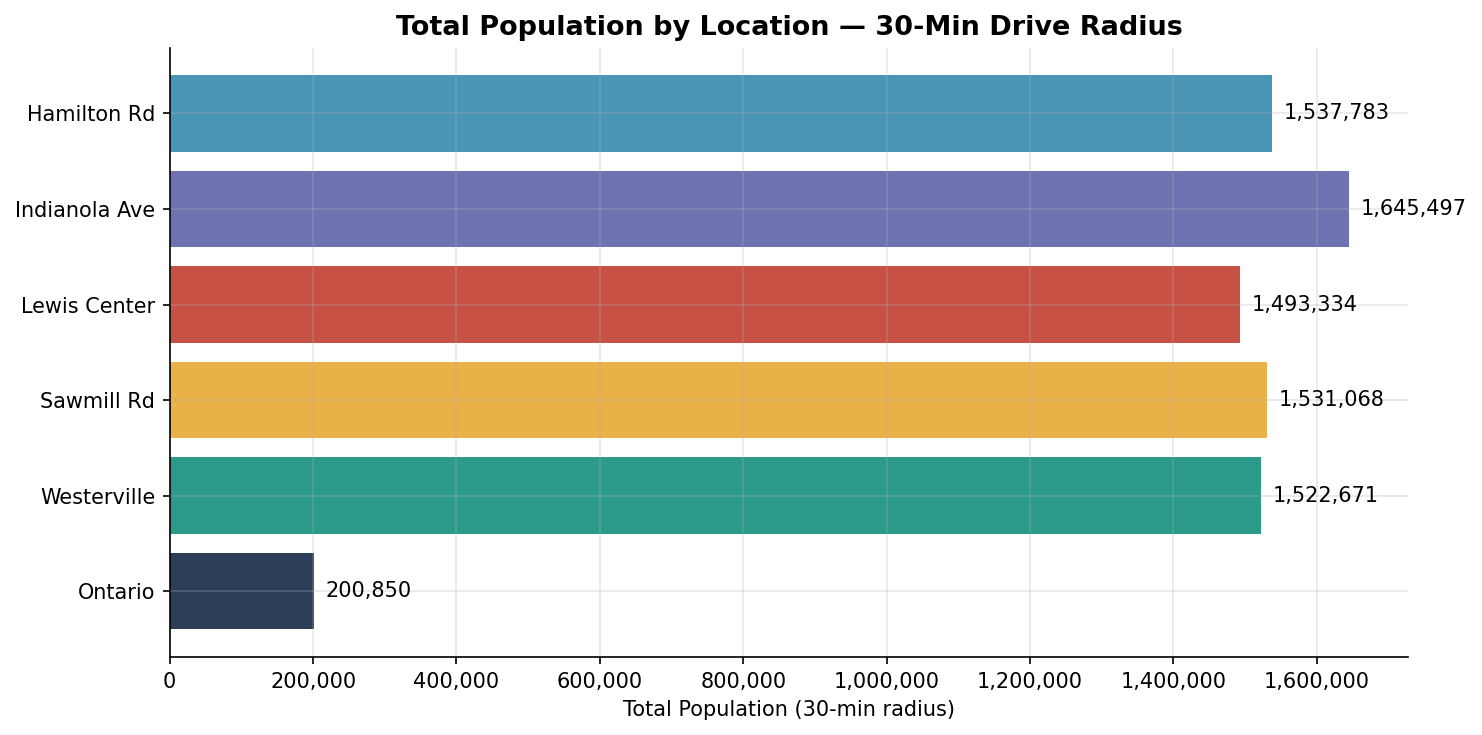

Chart 1 saved.


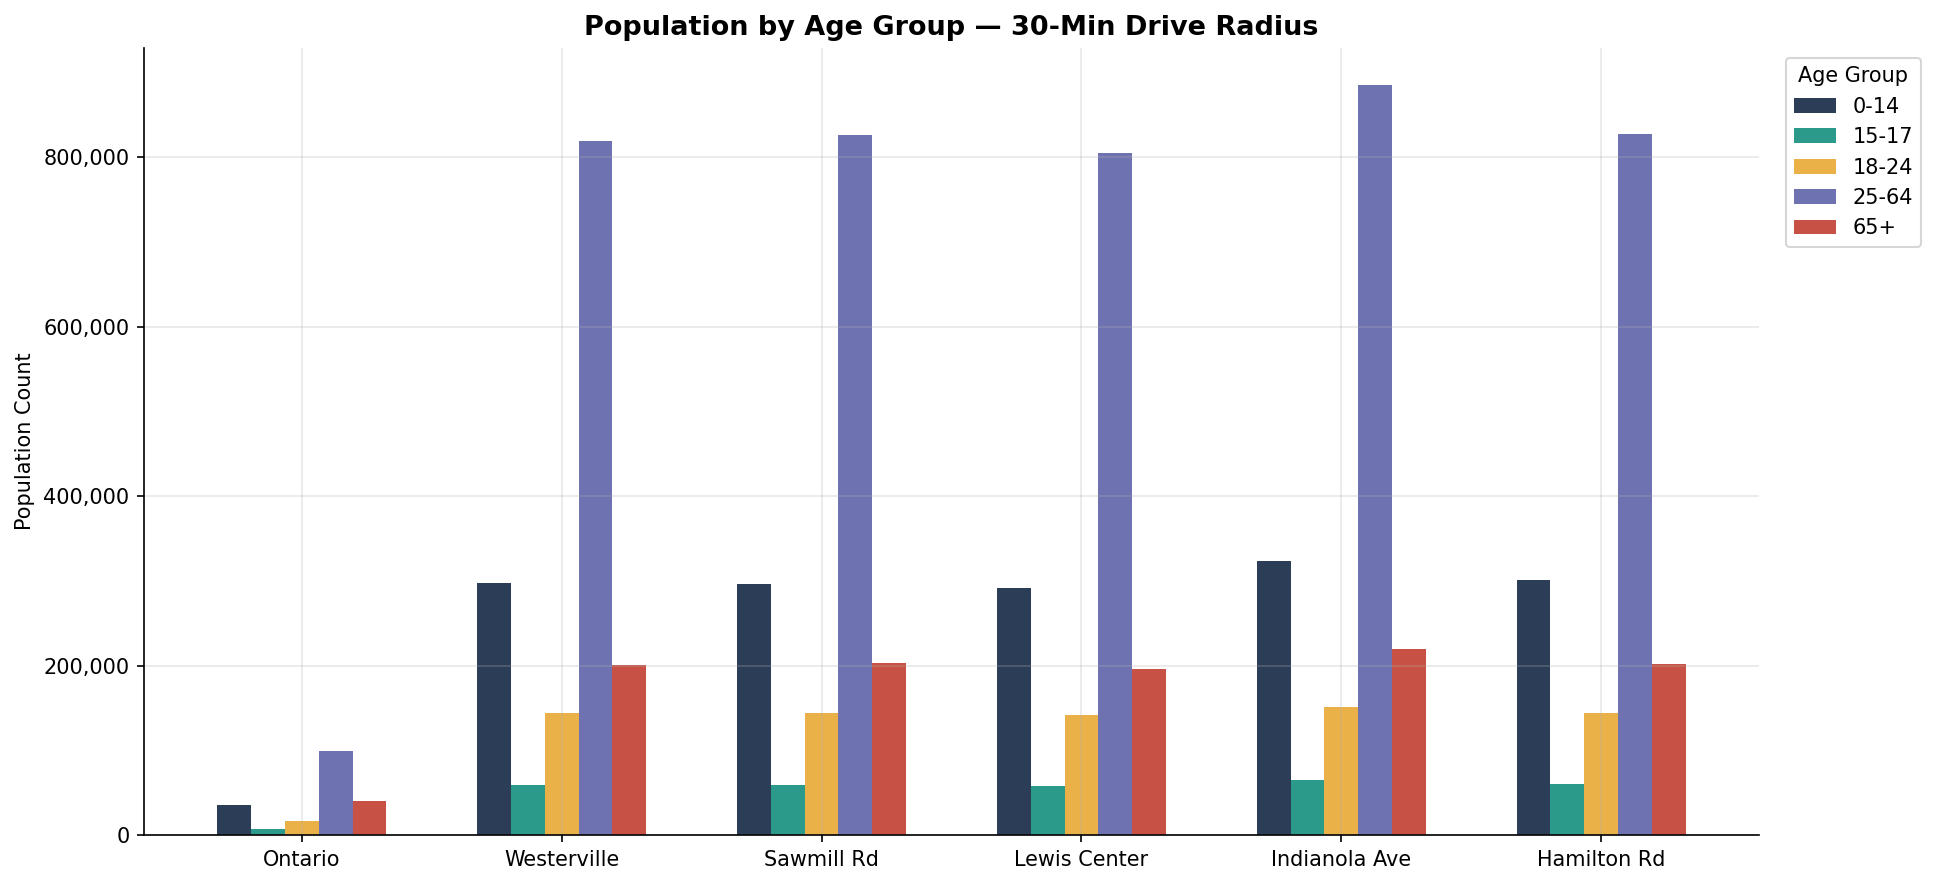

Chart 2 saved.


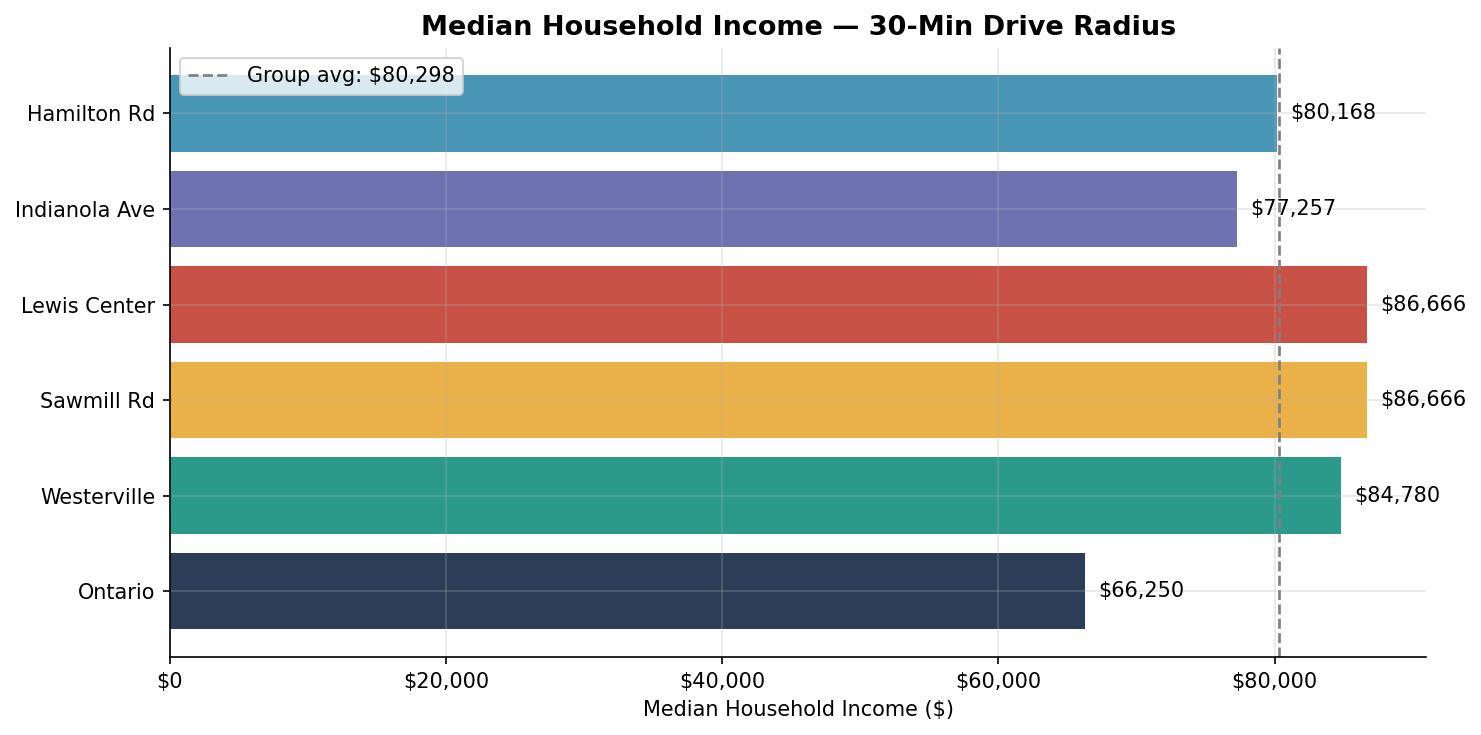

Chart 3 saved.


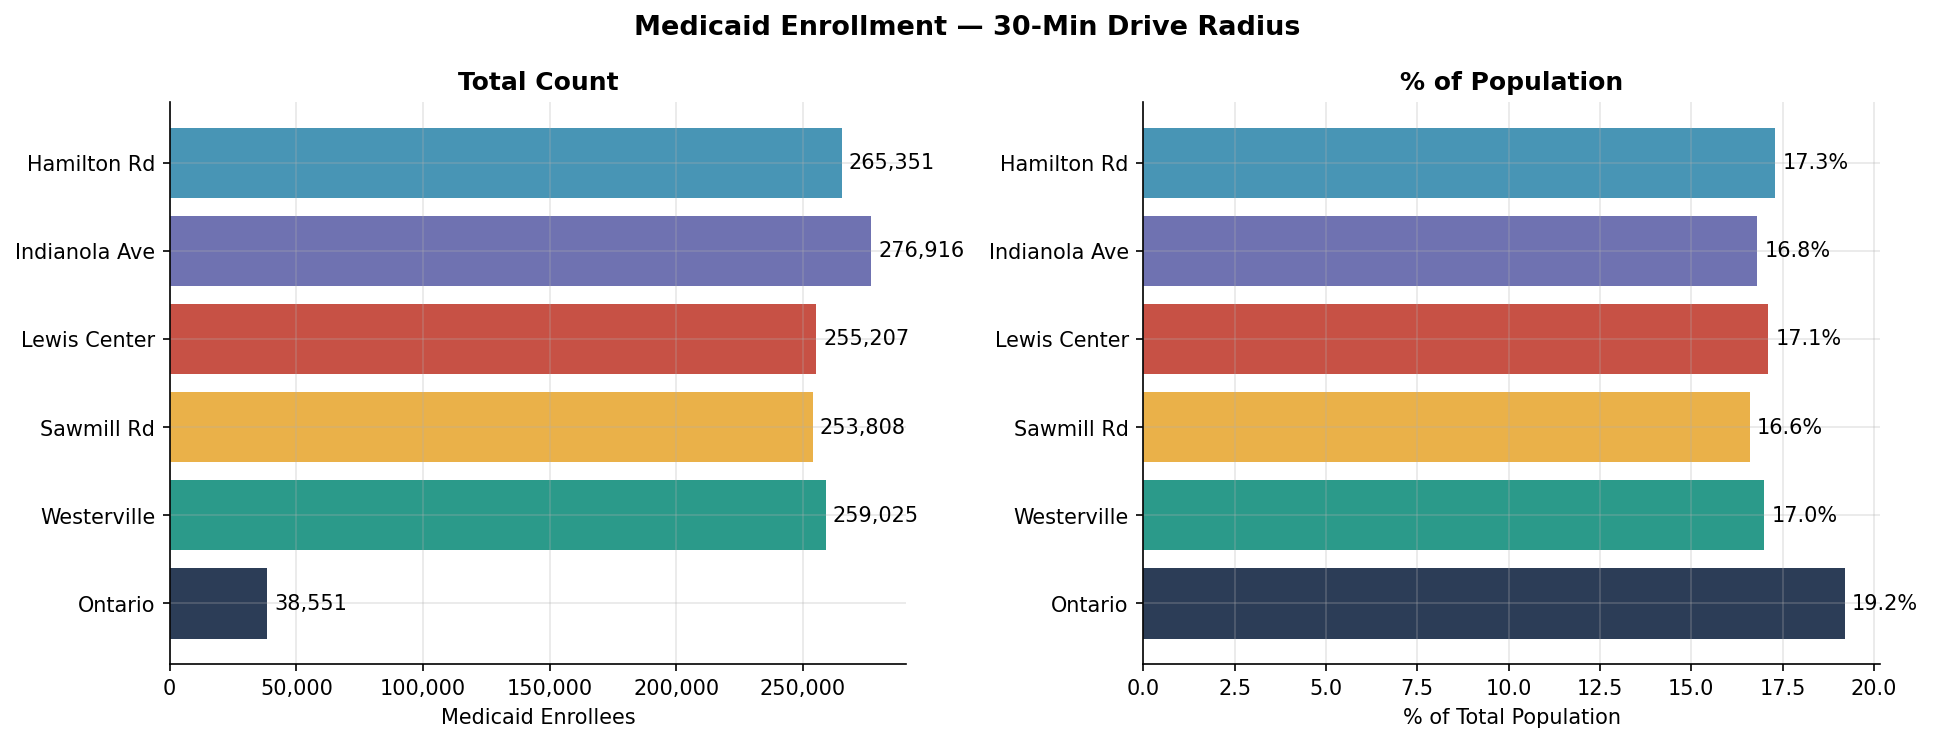

Chart 4 saved.


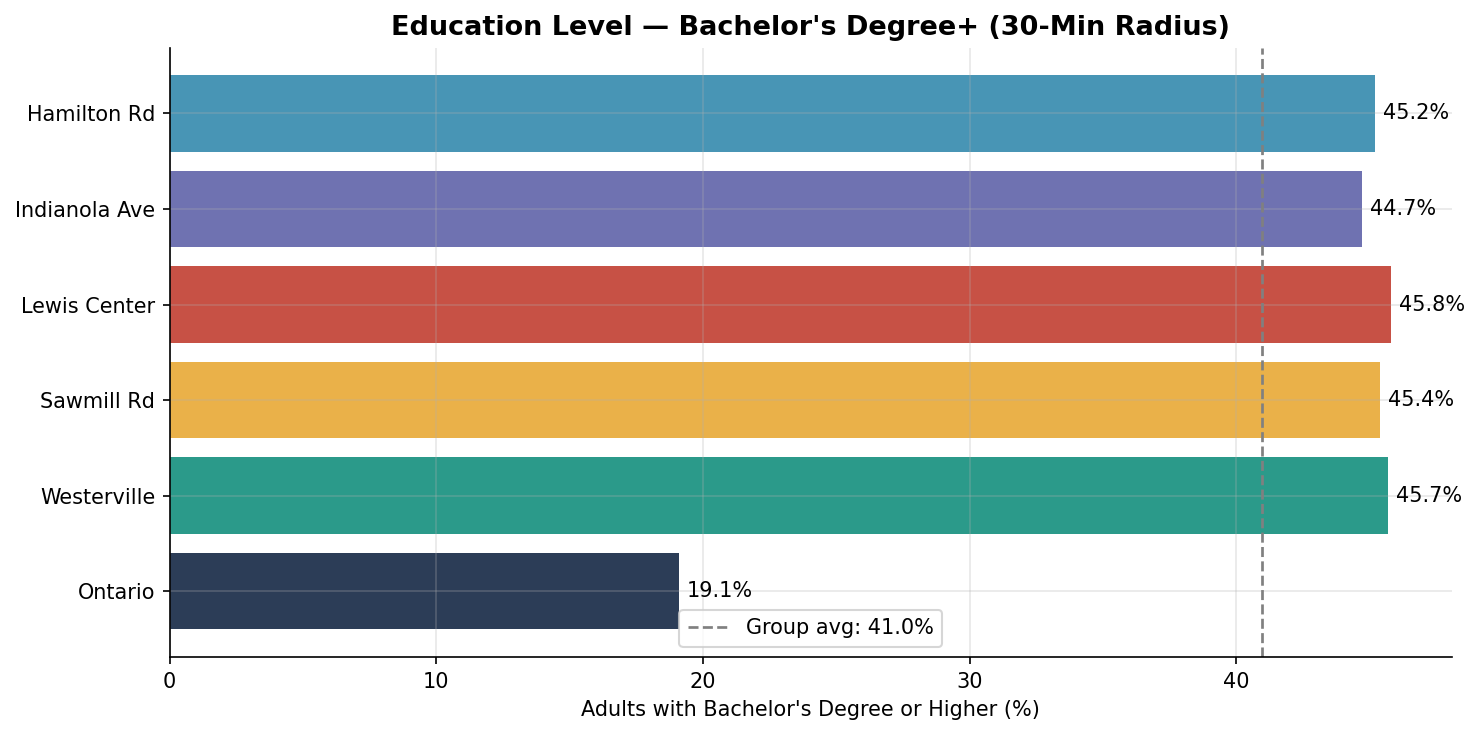

Chart 5 saved.


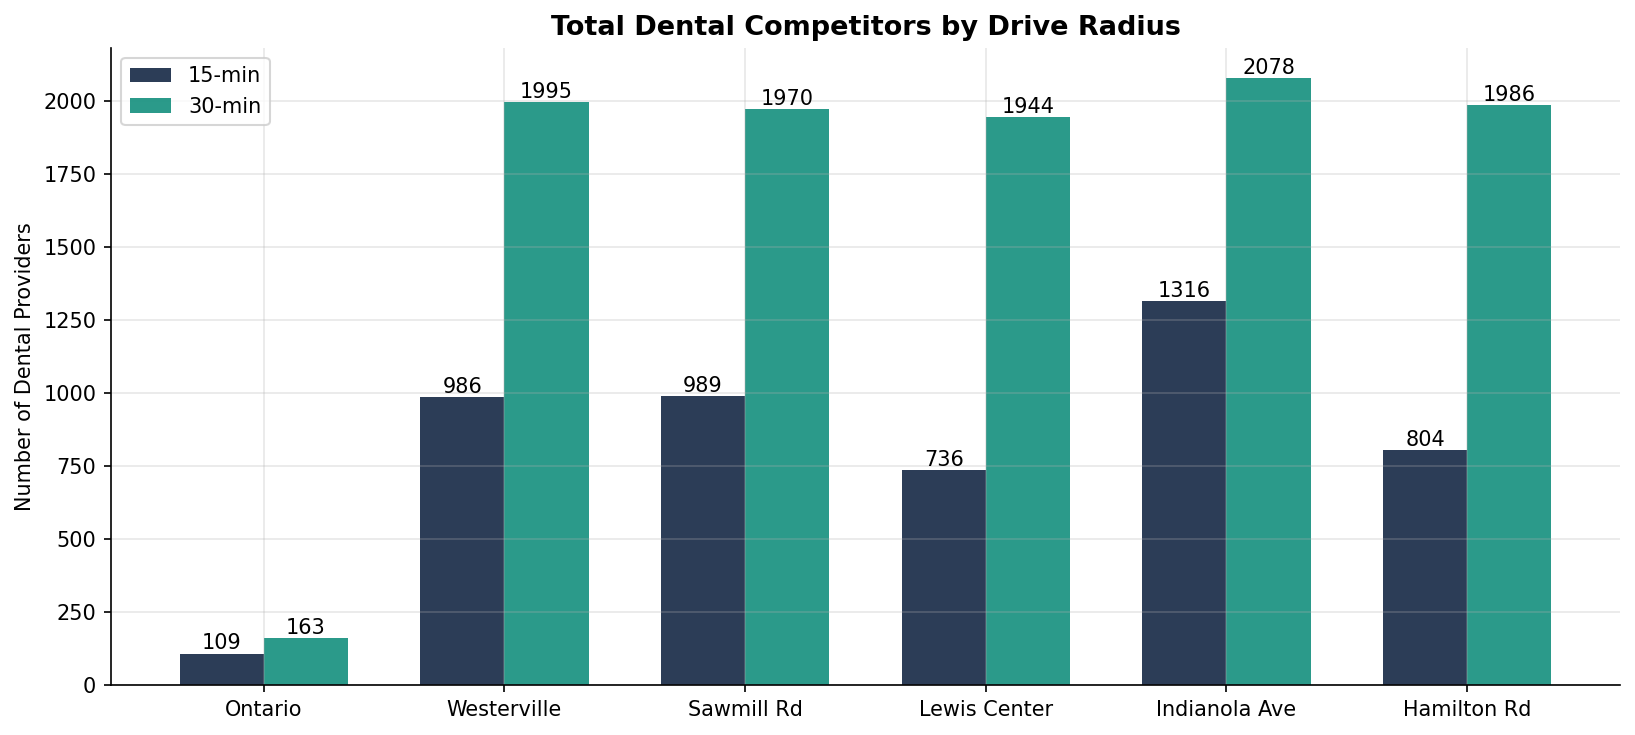

Chart 6 saved.


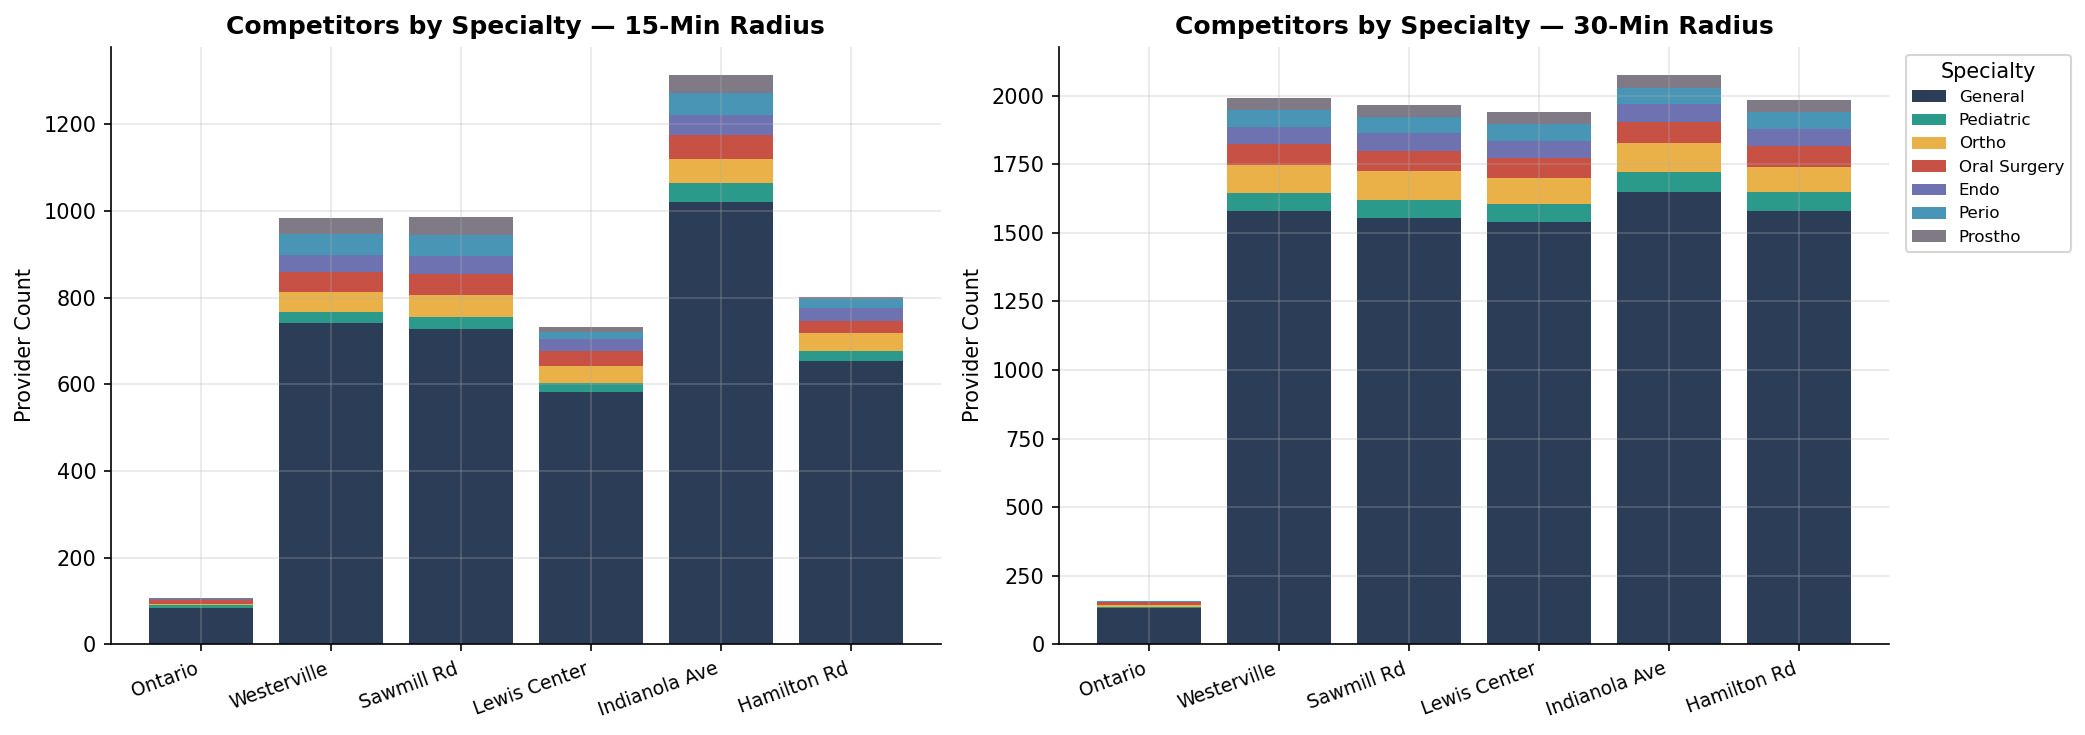

Chart 7 saved.


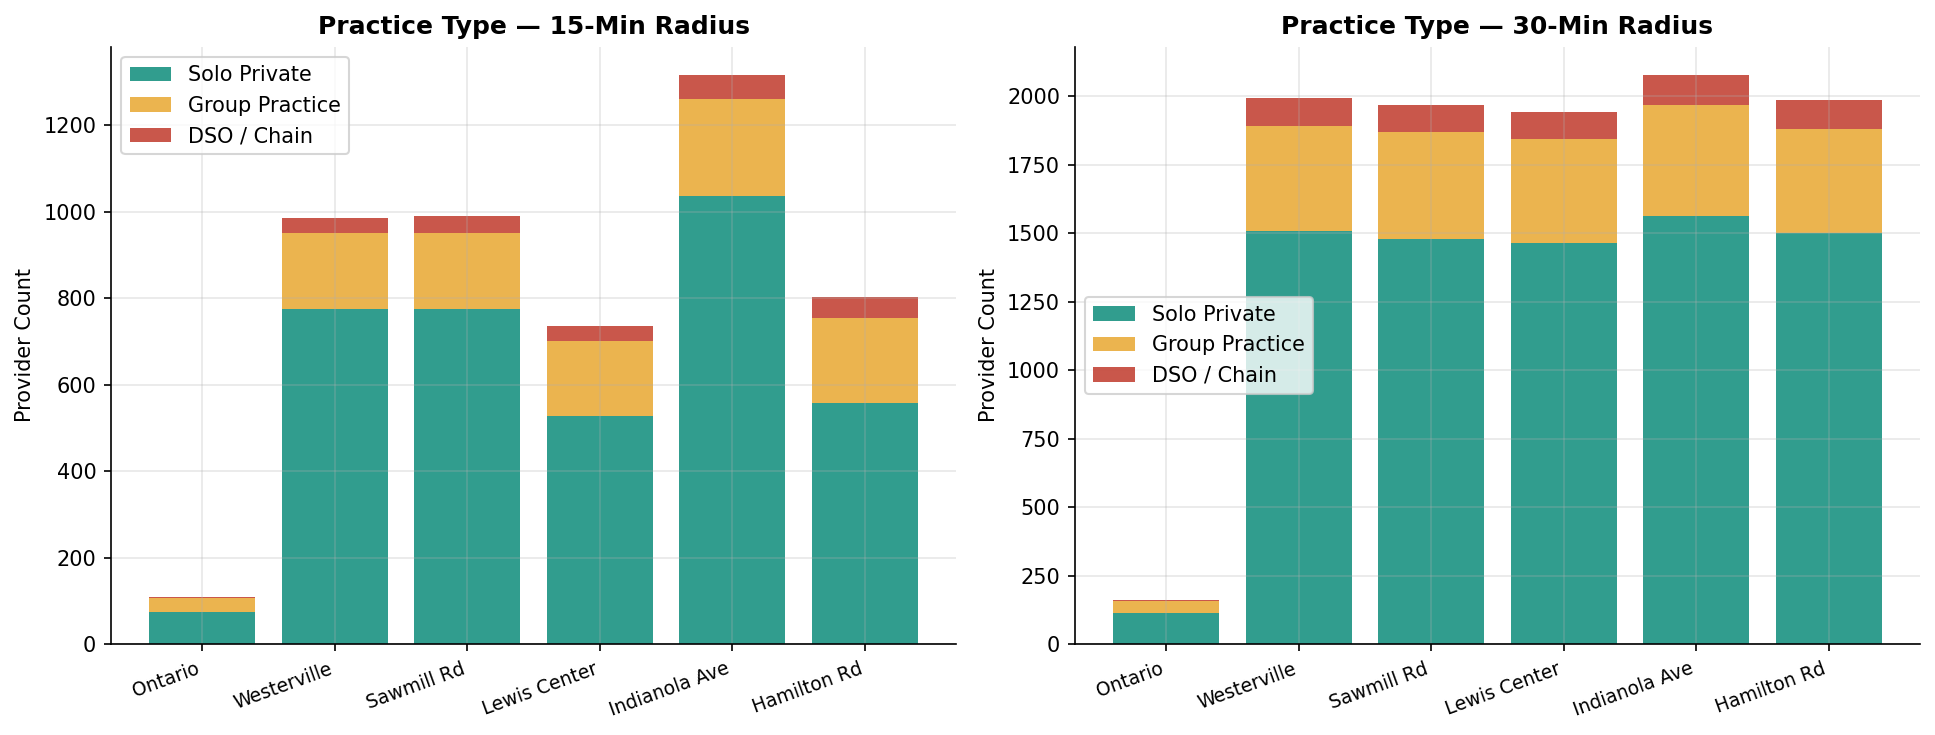

Chart 8 saved.

All charts saved to: ../charts/charts_m1


In [8]:
# CHART 1: Total Population
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(master["location_name"], master["total_population"], color=COLORS, alpha=0.88)
for bar, val in zip(bars, master["total_population"]):
    ax.text(bar.get_width() + master["total_population"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2, f"{val:,.0f}", va="center", fontsize=10)
ax.set_xlabel("Total Population (30-min radius)")
ax.set_title("Total Population by Location — 30-Min Drive Radius", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "01_total_population.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 1 saved.")

# CHART 2: Population by Age Group 
age_cols   = ["pop_0_14", "pop_15_17", "pop_18_24", "pop_25_64", "pop_65_plus"]
age_labels = ["0-14", "15-17", "18-24", "25-64", "65+"]
age_colors = ["#0F2240", "#0D8C7A", "#E8A730", "#5B5EA6", "#C0392B"]
x, width = np.arange(len(master)), 0.13
fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, lbl, clr) in enumerate(zip(age_cols, age_labels, age_colors)):
    ax.bar(x + i * width, master[col], width, label=lbl, color=clr, alpha=0.88)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(master["location_name"], fontsize=10)
ax.set_ylabel("Population Count")
ax.set_title("Population by Age Group — 30-Min Drive Radius", fontsize=13, fontweight="bold")
ax.legend(title="Age Group", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "02_population_by_age.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 2 saved.")

# CHART 3: Median Income
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(master["location_name"], master["median_income"], color=COLORS, alpha=0.88)
for bar, val in zip(bars, master["median_income"]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontsize=10)
avg = master["median_income"].mean()
ax.axvline(avg, color="grey", linestyle="--", linewidth=1.3, label=f"Group avg: ${avg:,.0f}")
ax.set_xlabel("Median Household Income ($)")
ax.set_title("Median Household Income — 30-Min Drive Radius", fontsize=13, fontweight="bold")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "03_median_income.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 3 saved.")

# CHART 4: Medicaid Enrollment 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].barh(master["location_name"], master["medicaid_total"], color=COLORS, alpha=0.88)
for bar, val in zip(bars, master["medicaid_total"]):
    axes[0].text(bar.get_width() + master["medicaid_total"].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2, f"{val:,.0f}", va="center", fontsize=10)
axes[0].set_xlabel("Medicaid Enrollees")
axes[0].set_title("Total Count", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
bars2 = axes[1].barh(master["location_name"], master["medicaid_pct"], color=COLORS, alpha=0.88)
for bar, val in zip(bars2, master["medicaid_pct"]):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=10)
axes[1].set_xlabel("% of Total Population")
axes[1].set_title("% of Population", fontweight="bold")
plt.suptitle("Medicaid Enrollment — 30-Min Drive Radius", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "04_medicaid.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 4 saved.")

# CHART 5: Education 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(master["location_name"], master["pct_bachelor_plus"], color=COLORS, alpha=0.88)
for bar, val in zip(bars, master["pct_bachelor_plus"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10)
avg_edu = master["pct_bachelor_plus"].mean()
ax.axvline(avg_edu, color="grey", linestyle="--", linewidth=1.3, label=f"Group avg: {avg_edu:.1f}%")
ax.set_xlabel("Adults with Bachelor's Degree or Higher (%)")
ax.set_title("Education Level — Bachelor's Degree+ (30-Min Radius)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "05_education.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 5 saved.")

# CHART 6: Total Competitors
x, width = np.arange(len(competitors)), 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b15 = ax.bar(x - width/2, competitors["total_15min"], width, label="15-min", color="#0F2240", alpha=0.88)
b30 = ax.bar(x + width/2, competitors["total_30min"], width, label="30-min", color="#0D8C7A", alpha=0.88)
for bar in list(b15) + list(b30):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(competitors["location_name"], fontsize=10)
ax.set_ylabel("Number of Dental Providers")
ax.set_title("Total Dental Competitors by Drive Radius", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "06_total_competitors.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 6 saved.")

# CHART 7: Competitors by Specialty
spec_cols   = ["general", "pediatric", "ortho", "oral_surgery", "endo", "perio", "prostho"]
spec_labels = ["General", "Pediatric", "Ortho", "Oral Surgery", "Endo", "Perio", "Prostho"]
spec_colors = ["#0F2240", "#0D8C7A", "#E8A730", "#C0392B", "#5B5EA6", "#2E86AB", "#6D6875"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tag, title in [(axes[0], "15min", "15-Min Radius"), (axes[1], "30min", "30-Min Radius")]:
    bottom = np.zeros(len(competitors))
    xpos   = np.arange(len(competitors))
    for col, lbl, clr in zip(spec_cols, spec_labels, spec_colors):
        vals = competitors[f"{col}_{tag}"].values.astype(float)
        ax.bar(xpos, vals, bottom=bottom, label=lbl, color=clr, alpha=0.88)
        bottom += vals
    ax.set_xticks(xpos)
    ax.set_xticklabels(competitors["location_name"], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Provider Count")
    ax.set_title(f"Competitors by Specialty — {title}", fontweight="bold")
    if tag == "30min":
        ax.legend(title="Specialty", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "07_competitors_by_specialty.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 7 saved.")

# CHART 8: Practice Type 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tag, title in [(axes[0], "15min", "15-Min Radius"), (axes[1], "30min", "30-Min Radius")]:
    xpos  = np.arange(len(competitors))
    solo  = competitors[f"solo_{tag}"].values.astype(float)
    group = competitors[f"group_{tag}"].values.astype(float)
    dso   = competitors[f"dso_{tag}"].values.astype(float)
    ax.bar(xpos, solo,  label="Solo Private",   color="#0D8C7A", alpha=0.85)
    ax.bar(xpos, group, bottom=solo,            label="Group Practice", color="#E8A730", alpha=0.85)
    ax.bar(xpos, dso,   bottom=solo + group,    label="DSO / Chain",    color="#C0392B", alpha=0.85)
    ax.set_xticks(xpos)
    ax.set_xticklabels(competitors["location_name"], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Provider Count")
    ax.set_title(f"Practice Type — {title}", fontweight="bold")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "08_practice_type.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 8 saved.")

print("\nAll charts saved to:", CHARTS_PATH)

In [7]:
# SUMMARY
print("=" * 70)
print("MODULE 1 — SUMMARY STATISTICS")
print("=" * 70)

print(f"\n{'LOCATION':<16} {'POPULATION':>12} {'INCOME':>12} "
      f"{'MEDICAID%':>10} {'BACH+%':>8} {'COMP-15':>8} {'COMP-30':>8}")
print("-" * 70)
for _, row in master.iterrows():
    print(f"{row['location_name']:<16} "
          f"{row['total_population']:>12,.0f} "
          f"${row['median_income']:>11,.0f} "
          f"{row['medicaid_pct']:>9.1f}% "
          f"{row['pct_bachelor_plus']:>7.1f}% "
          f"{row['total_15min']:>8} "
          f"{row['total_30min']:>8}")

print(f"\n{'LOCATION':<16} {'GEN-15':>8} {'GEN-30':>8} "
      f"{'DSO-15':>8} {'GRP-15':>8} {'SOLO-15':>9}")
print("-" * 70)
for _, row in competitors.iterrows():
    print(f"{row['location_name']:<16} "
          f"{row['general_15min']:>8} "
          f"{row['general_30min']:>8} "
          f"{row['dso_15min']:>8} "
          f"{row['group_15min']:>8} "
          f"{row['solo_15min']:>9}")

print(f"\n{'LOCATION':<16} {'NEARBY ZIPs':>12}")
print("-" * 30)
for _, row in master.iterrows():
    print(f"{row['location_name']:<16} {row['nearby_zip_count']:>12}")

print("\nOutputs saved:")
print(f"  {os.path.join(OUTPUT_PATH, 'master_dataset.csv')}")
print(f"  {os.path.join(OUTPUT_PATH, 'competitors_summary.csv')}")
print(f"  {CHARTS_PATH}/ (8 PNG files)")

MODULE 1 — SUMMARY STATISTICS

LOCATION           POPULATION       INCOME  MEDICAID%   BACH+%  COMP-15  COMP-30
----------------------------------------------------------------------
Ontario               200,850 $     66,250      19.2%    19.1%      109      163
Westerville         1,522,671 $     84,780      17.0%    45.7%      986     1995
Sawmill Rd          1,531,068 $     86,666      16.6%    45.4%      989     1970
Lewis Center        1,493,334 $     86,666      17.1%    45.8%      736     1944
Indianola Ave       1,645,497 $     77,257      16.8%    44.7%     1316     2078
Hamilton Rd         1,537,783 $     80,168      17.3%    45.2%      804     1986

LOCATION           GEN-15   GEN-30   DSO-15   GRP-15   SOLO-15
----------------------------------------------------------------------
Ontario                84      132        2       31        76
Westerville           742     1579       35      175       776
Sawmill Rd            727     1554       38      176       775
Lewis C